# Ridge Baseline Comparison

This notebook checks the processed Tg splits, compares their distributions, and evaluates closed-form Ridge regression over several regularization strengths.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

c:\Users\simon\Desktop\Regroupement\IA_for_chemistry\AI4Chem


In [3]:
import csv
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D # legend spe
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
fc = '#e0e0e0'
ec = 'black'
csfont = {'fontname':'Times New Roman'}
import numpy as np

from src.data_utils import (
    TRAIN_DATA_PATH,
    VALIDATION_DATA_PATH,
    TEST_DATA_PATH,
    TARGET_COLUMN,
    RELIABILITY_COLUMN,
    load_tg_csv,
)
from src.featurize import psmiles_to_nparray
from src.models import LinearRegressionClosedForm, RidgeRegressionClosedForm, RandomForest, XGBoostModel, SupportVectorModel, ElasticNetModel
from src.train import evaluate_predictions, fit_and_predict

plt.style.use("default")

## Load Processed Splits

In [4]:
train_psmiles, y_train = load_tg_csv(TRAIN_DATA_PATH)
validation_psmiles, y_validation = load_tg_csv(VALIDATION_DATA_PATH)
test_psmiles, y_test = load_tg_csv(TEST_DATA_PATH)

print("train", len(train_psmiles), y_train.shape)
print("validation", len(validation_psmiles), y_validation.shape)
print("test", len(test_psmiles), y_test.shape)

train 5154 (5154,)
validation 1104 (1104,)
test 1105 (1105,)


In [5]:
def summarize_split(path):
    with path.open(newline="", encoding="utf-8") as file:
        rows = list(csv.DictReader(file))

    tg_values = np.array([float(row[TARGET_COLUMN]) for row in rows])
    reliability_counts = Counter(row[RELIABILITY_COLUMN] for row in rows)
    return {
        "n_rows": len(rows),
        "tg_mean": tg_values.mean(),
        "tg_std": tg_values.std(),
        "tg_min": tg_values.min(),
        "tg_max": tg_values.max(),
        "reliability_counts": reliability_counts,
    }

split_summaries = {
    "train": summarize_split(TRAIN_DATA_PATH),
    "validation": summarize_split(VALIDATION_DATA_PATH),
    "test": summarize_split(TEST_DATA_PATH),
}

for split_name, summary in split_summaries.items():
    print(split_name)
    print("  rows:", summary["n_rows"])
    print("  Tg mean/std:", round(summary["tg_mean"], 2), round(summary["tg_std"], 2))
    print("  Tg min/max:", round(summary["tg_min"], 2), round(summary["tg_max"], 2))
    print("  reliability:", dict(summary["reliability_counts"]))

train
  rows: 5154
  Tg mean/std: 416.78 112.94
  Tg min/max: 134.15 768.15
  reliability: {'black': 4962, 'yellow': 92, 'gold': 100}
validation
  rows: 1104
  Tg mean/std: 415.73 113.29
  Tg min/max: 149.0 701.15
  reliability: {'black': 1063, 'yellow': 20, 'gold': 21}
test
  rows: 1105
  Tg mean/std: 419.83 111.04
  Tg min/max: 144.15 763.15
  reliability: {'black': 1063, 'gold': 22, 'yellow': 20}


## Compare Tg and Reliability Distributions

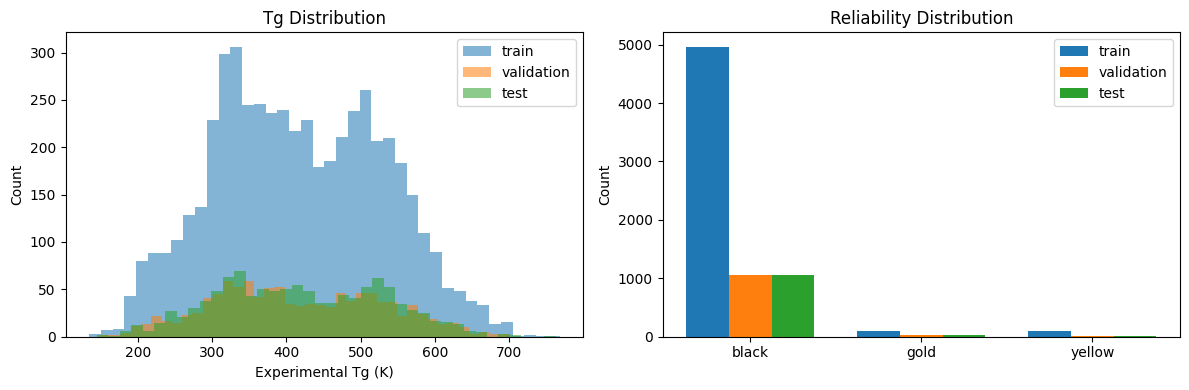

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=40, alpha=0.55, label="train")
axes[0].hist(y_validation, bins=40, alpha=0.55, label="validation")
axes[0].hist(y_test, bins=40, alpha=0.55, label="test")
axes[0].set_xlabel("Experimental Tg (K)")
axes[0].set_ylabel("Count")
axes[0].set_title("Tg Distribution")
axes[0].legend()

reliability_labels = sorted({
    label
    for summary in split_summaries.values()
    for label in summary["reliability_counts"]
})
x = np.arange(len(reliability_labels))
width = 0.25

for offset, split_name in zip([-width, 0, width], ["train", "validation", "test"]):
    counts = [split_summaries[split_name]["reliability_counts"].get(label, 0) for label in reliability_labels]
    axes[1].bar(x + offset, counts, width=width, label=split_name)

axes[1].set_xticks(x)
axes[1].set_xticklabels(reliability_labels)
axes[1].set_ylabel("Count")
axes[1].set_title("Reliability Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## Featurize PSMILES

In [7]:
X_train = psmiles_to_nparray(train_psmiles)
X_validation = psmiles_to_nparray(validation_psmiles)
X_test = psmiles_to_nparray(test_psmiles)

print("X_train", X_train.shape)
print("X_validation", X_validation.shape)
print("X_test", X_test.shape)
print("active bits per train molecule: mean/min/max", X_train.sum(axis=1).mean(), X_train.sum(axis=1).min(), X_train.sum(axis=1).max())

X_train (5154, 2048)
X_validation (1104, 2048)
X_test (1105, 2048)
active bits per train molecule: mean/min/max 39.83236321303842 6 114


## OLS Sanity Check

Closed-form OLS may fail because Morgan fingerprint columns can be linearly dependent, making `X.T @ X` singular.

In [8]:
try:
    ols_model = LinearRegressionClosedForm()
    y_pred_validation, y_pred_test = fit_and_predict(ols_model, X_train, y_train, X_validation, X_test)
    ols_scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
    print(ols_scores)
except np.linalg.LinAlgError as error:
    print("OLS failed:", error)

OLS failed: Singular matrix


# Ridge

## Ridge Alpha Sweep

In [13]:
alphas = np.logspace(-4, 4, 17)
ridge_results = []

for alpha in alphas:
    model = RidgeRegressionClosedForm(alpha=alpha)
    y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
    scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
    scores["alpha"] = alpha
    ridge_results.append(scores)

best_result = min(ridge_results, key=lambda result: result["rmse_validation"])
best_alpha = best_result["alpha"]

print("Best alpha by validation RMSE:", best_alpha)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best alpha by validation RMSE: 10.0
mse_validation: 1781.0965
mse_test: 2000.4887
mae_validation: 31.4494
mae_test: 31.9435
rmse_validation: 42.2030
rmse_test: 44.7268
r2_validation: 0.8612
r2_test: 0.8377
alpha: 10.0000


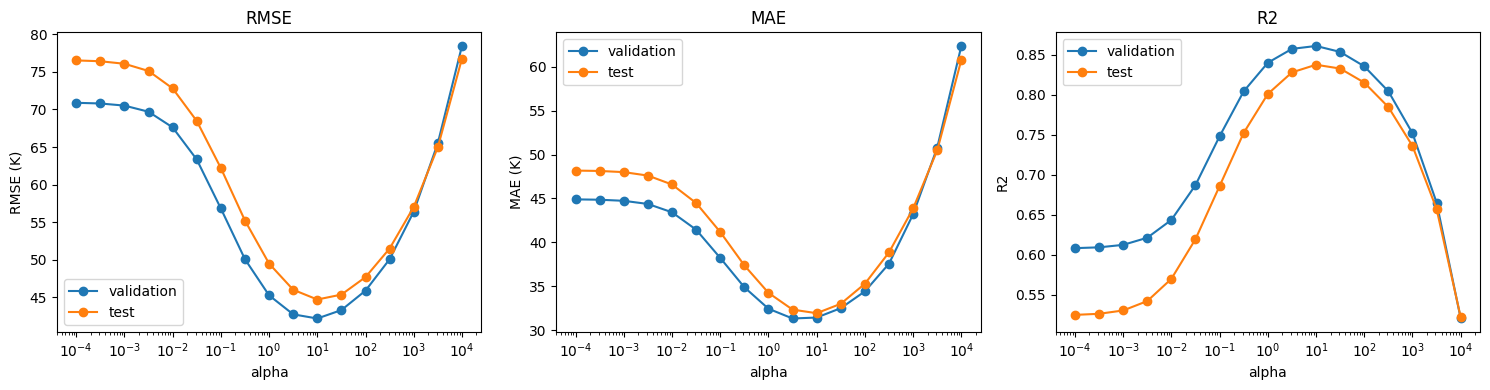

In [14]:
alpha_values = np.array([result["alpha"] for result in ridge_results])
validation_rmse = np.array([result["rmse_validation"] for result in ridge_results])
test_rmse = np.array([result["rmse_test"] for result in ridge_results])
validation_mae = np.array([result["mae_validation"] for result in ridge_results])
test_mae = np.array([result["mae_test"] for result in ridge_results])
validation_r2 = np.array([result["r2_validation"] for result in ridge_results])
test_r2 = np.array([result["r2_test"] for result in ridge_results])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(alpha_values, validation_rmse, marker="o", label="validation")
axes[0].plot(alpha_values, test_rmse, marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("RMSE (K)")
axes[0].set_title("RMSE")
axes[0].legend()

axes[1].plot(alpha_values, validation_mae, marker="o", label="validation")
axes[1].plot(alpha_values, test_mae, marker="o", label="test")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("MAE (K)")
axes[1].set_title("MAE")
axes[1].legend()

axes[2].plot(alpha_values, validation_r2, marker="o", label="validation")
axes[2].plot(alpha_values, test_r2, marker="o", label="test")
axes[2].set_xscale("log")
axes[2].set_xlabel("alpha")
axes[2].set_ylabel("R2")
axes[2].set_title("R2")
axes[2].legend()

plt.tight_layout()
plt.show()

## Best Ridge Predictions

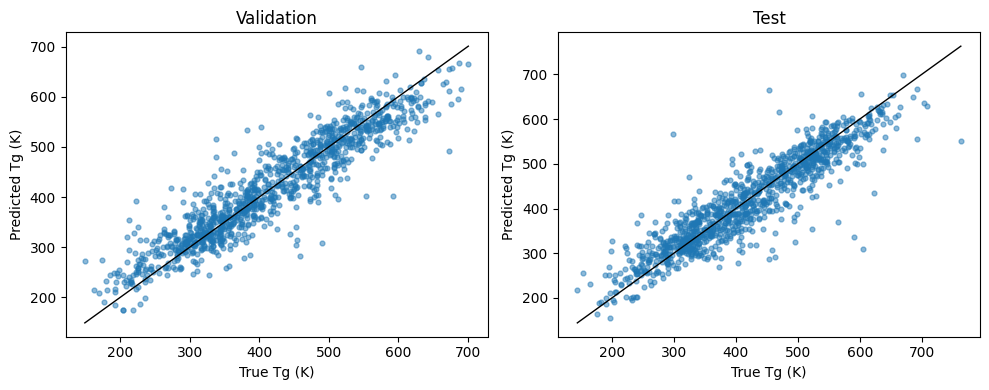

In [15]:
best_model = RidgeRegressionClosedForm(alpha=best_alpha)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

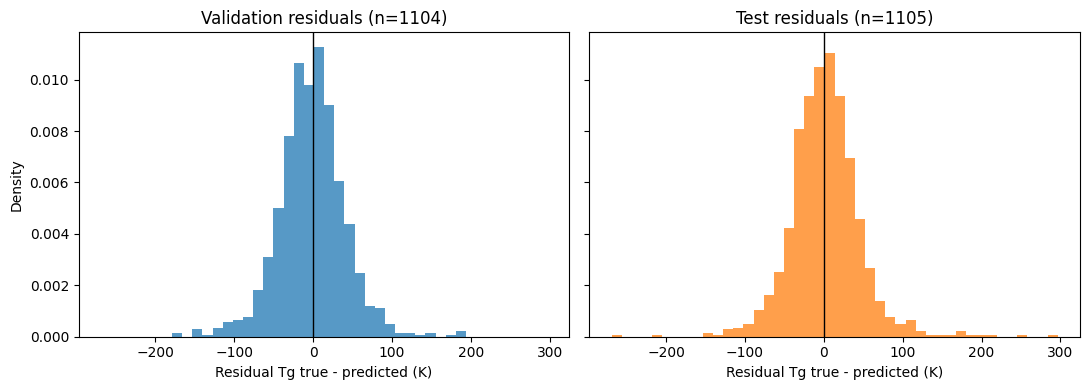

In [16]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()

# Elastic Net

In [31]:
alphas = np.linspace(0.01, 0.4, 5, endpoint=True)
l1_ratios = np.linspace(0.8, 0.9, 3, endpoint=True)
elastic_net_results = []

for alpha in alphas:
    for l1_ratio in l1_ratios:
        model = ElasticNetModel(alpha=alpha, l1_ratio=l1_ratio)
        y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
        scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
        scores["alpha"] = alpha
        scores["l1_ratio"] = l1_ratio
        elastic_net_results.append(scores)

In [32]:
best_result = min(elastic_net_results, key=lambda result: result["rmse_validation"])
best_alpha = best_result["alpha"]
best_l1_ratio = best_result["l1_ratio"]

print("Best alpha by validation RMSE:", best_alpha)
print("Best l1_ratio by validation RMSE:", best_l1_ratio)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best alpha by validation RMSE: 0.01
Best l1_ratio by validation RMSE: 0.8500000000000001
mse_validation: 1797.6184
mse_test: 1990.6222
mae_validation: 31.5895
mae_test: 31.9059
rmse_validation: 42.3983
rmse_test: 44.6164
r2_validation: 0.8599
r2_test: 0.8385
alpha: 0.0100
l1_ratio: 0.8500


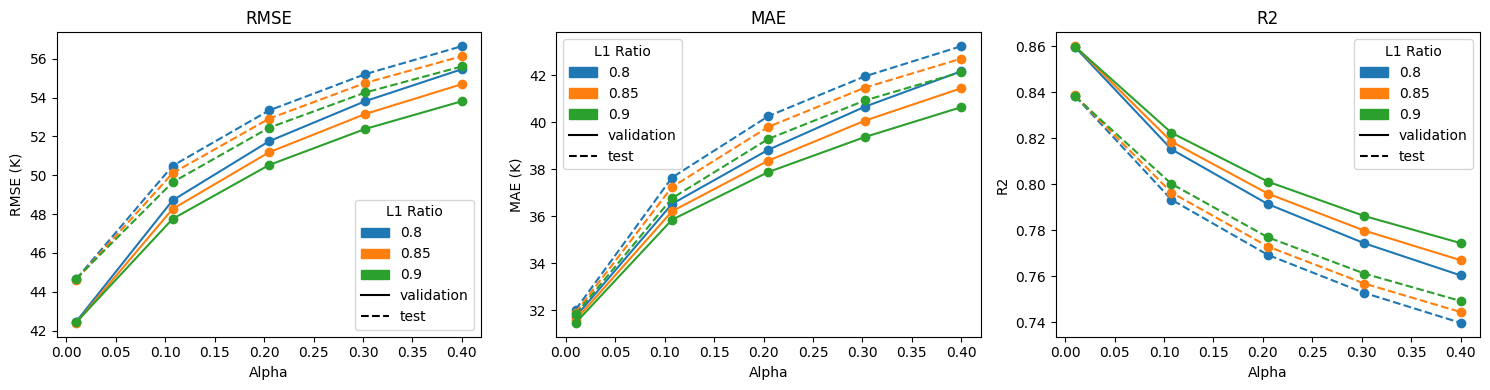

In [33]:
l1_ratio_values = np.unique([result["l1_ratio"] for result in elastic_net_results])

color_map = {0.8: "tab:blue", 0.85: "tab:orange", 0.9: "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for l1_ratio in l1_ratio_values:
    subset = [result for result in elastic_net_results if result["l1_ratio"] == l1_ratio]
    color = color_map[round(l1_ratio, 3)]

    alpha_values = np.array([result["alpha"] for result in subset])
    validation_rmse  = np.array([result["rmse_validation"] for result in subset])
    test_rmse        = np.array([result["rmse_test"]        for result in subset])
    validation_mae   = np.array([result["mae_validation"]   for result in subset])
    test_mae         = np.array([result["mae_test"]         for result in subset])
    validation_r2    = np.array([result["r2_validation"]    for result in subset])
    test_r2          = np.array([result["r2_test"]          for result in subset])

    axes[0].plot(alpha_values, validation_rmse, marker="o", linestyle="-",  color=color)
    axes[0].plot(alpha_values, test_rmse,       marker="o", linestyle="--", color=color)

    axes[1].plot(alpha_values, validation_mae,  marker="o", linestyle="-",  color=color)
    axes[1].plot(alpha_values, test_mae,        marker="o", linestyle="--", color=color)

    axes[2].plot(alpha_values, validation_r2,   marker="o", linestyle="-",  color=color)
    axes[2].plot(alpha_values, test_r2,         marker="o", linestyle="--", color=color)

# Legend handles (shared across all subplots)
line1_shape = mlines.Line2D([], [], color='black', linestyle='-',  label='validation')
line2_shape = mlines.Line2D([], [], color='black', linestyle='--', label='test')
blue   = mpatches.Patch(color='tab:blue',   label='0.8')
orange = mpatches.Patch(color='tab:orange', label='0.85')
green  = mpatches.Patch(color='tab:green',  label='0.9')

for ax, ylabel, title in zip(axes,
                              ["RMSE (K)", "MAE (K)", "R2"],
                              ["RMSE",     "MAE",     "R2"]):
    ax.set_xlabel("Alpha")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(handles=[blue, orange, green, line1_shape, line2_shape],
              loc='best', ncol=1, title='L1 Ratio')

plt.tight_layout()
plt.show()

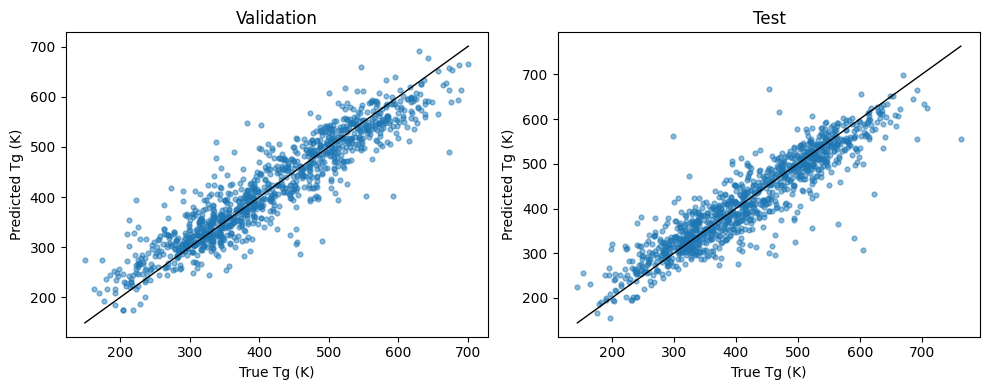

In [35]:
best_model = ElasticNetModel(alpha=best_alpha, l1_ratio=best_l1_ratio)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

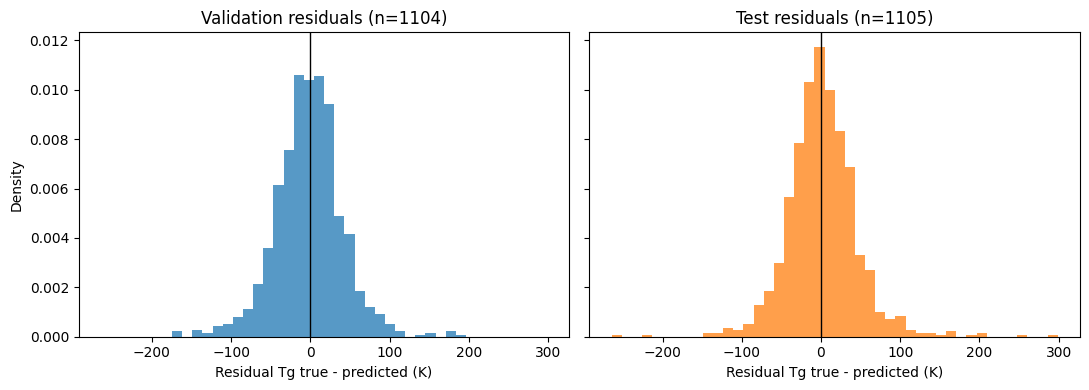

In [36]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()

# Random Forest

In [8]:
estimators = np.linspace(10, 100, 5, endpoint=True)
rf_results = []

for n_estimators in estimators:
    model = RandomForest(n_estimators=int(n_estimators))
    y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
    scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
    scores["n_estimators"] = n_estimators
    rf_results.append(scores)

In [9]:
best_result = min(rf_results, key=lambda result: result["rmse_validation"])
best_n_estimator = int(best_result["n_estimators"])

print("Best n-estimators by validation RMSE:", best_n_estimator)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best n-estimators by validation RMSE: 100
mse_validation: 1482.9417
mse_test: 1853.8157
mae_validation: 27.1762
mae_test: 28.2693
rmse_validation: 38.5090
rmse_test: 43.0560
r2_validation: 0.8845
r2_test: 0.8496
n_estimators: 100.0000


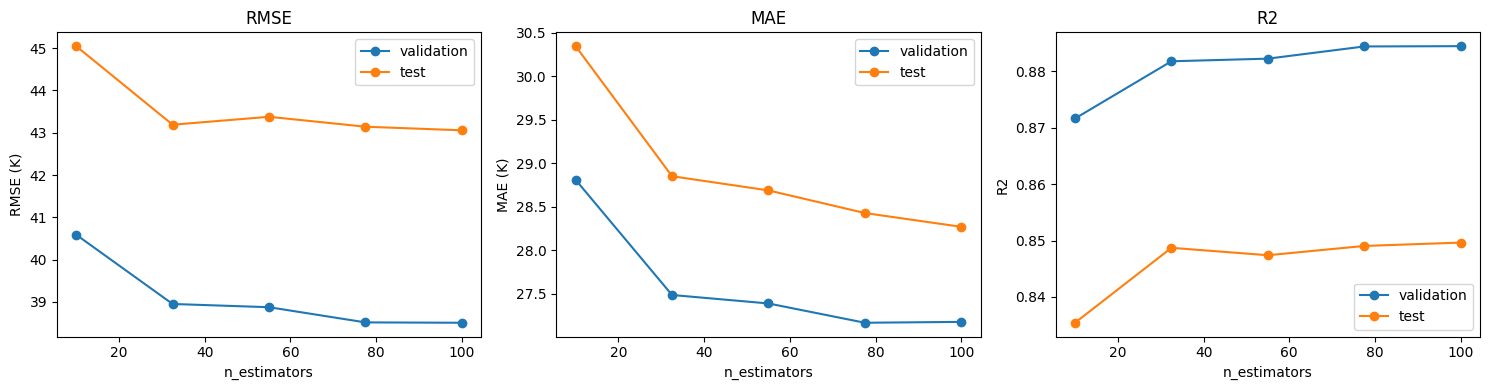

R2 for all parameters: [0.83543162 0.84871272 0.84740011 0.849045   0.84963872]


In [ ]:
n_estimators_values = np.array([result["n_estimators"] for result in rf_results])
validation_rmse = np.array([result["rmse_validation"] for result in rf_results])
test_rmse = np.array([result["rmse_test"] for result in rf_results])
validation_mae = np.array([result["mae_validation"] for result in rf_results])
test_mae = np.array([result["mae_test"] for result in rf_results])
validation_r2 = np.array([result["r2_validation"] for result in rf_results])
test_r2 = np.array([result["r2_test"] for result in rf_results])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(n_estimators_values, validation_rmse, marker="o", label="validation")
axes[0].plot(n_estimators_values, test_rmse, marker="o", label="test")
#axes[0].set_xscale("log")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("RMSE (K)")
axes[0].set_title("RMSE")
axes[0].legend()

axes[1].plot(n_estimators_values, validation_mae, marker="o", label="validation")
axes[1].plot(n_estimators_values, test_mae, marker="o", label="test")
#axes[1].set_xscale("log")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("MAE (K)")
axes[1].set_title("MAE")
axes[1].legend()

axes[2].plot(n_estimators_values, validation_r2, marker="o", label="validation")
axes[2].plot(n_estimators_values, test_r2, marker="o", label="test")
#axes[2].set_xscale("log")
axes[2].set_xlabel("n_estimators")
axes[2].set_ylabel("R2")
axes[2].set_title("R2")
axes[2].legend()

plt.tight_layout()
plt.show()

## Best RF predictions

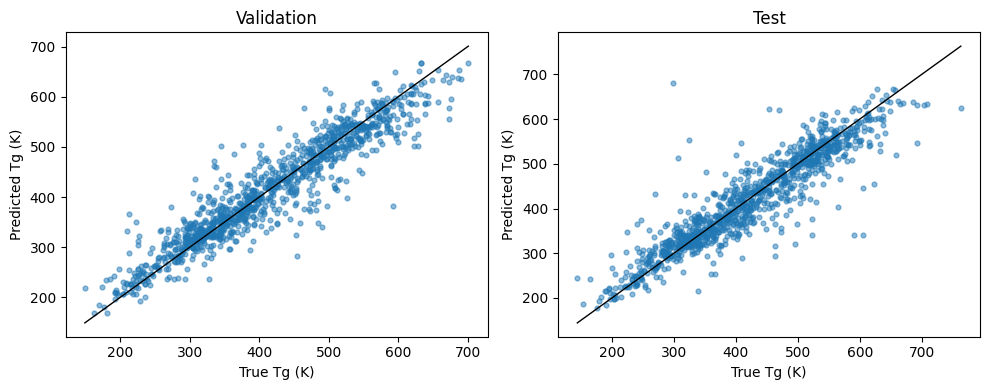

In [11]:
best_model = RandomForest(n_estimators=best_n_estimator)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

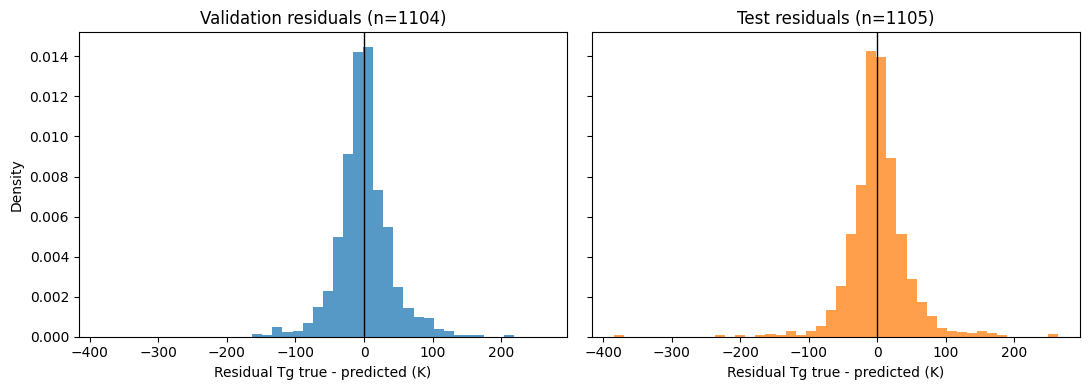

In [12]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()

# XGBoost

In [29]:
estimators = np.linspace(10, 150, 5, endpoint=True)
learnings = np.linspace(0.1, 0.5, 3, endpoint=True)
xgb_results = []

for n_estimators in estimators:
    for learning_rate in learnings:
        model = XGBoostModel(n_estimators=int(n_estimators), learning_rate=learning_rate)
        y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
        scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
        scores["n_estimators"] = n_estimators
        scores["learning_rate"] = learning_rate
        xgb_results.append(scores)

In [30]:
best_result = min(xgb_results, key=lambda result: result["rmse_validation"])
best_n_estimator = int(best_result["n_estimators"])
best_learning_rate = best_result["learning_rate"]

print("Best n-estimators by validation RMSE:", best_n_estimator)
print("Best learning rate by validation RMSE:", best_learning_rate)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best n-estimators by validation RMSE: 150
Best learning rate by validation RMSE: 0.30000000000000004
mse_validation: 1460.7510
mse_test: 1865.8706
mae_validation: 27.2910
mae_test: 29.2396
rmse_validation: 38.2198
rmse_test: 43.1957
r2_validation: 0.8862
r2_test: 0.8487
n_estimators: 150.0000
learning_rate: 0.3000


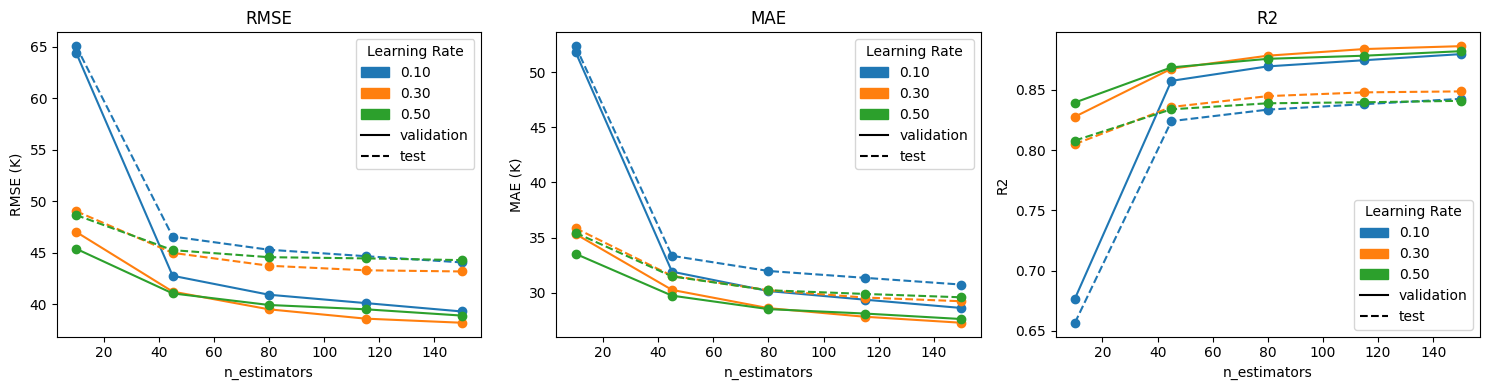

In [31]:
learning_rate_values = np.unique([result["learning_rate"] for result in xgb_results])

color_map = {0.1: "tab:blue", 0.3: "tab:orange", 0.5: "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for lr in learning_rate_values:
    subset = [result for result in xgb_results if result["learning_rate"] == lr]
    color = color_map[round(lr, 2)]

    n_estimators_values = np.array([result["n_estimators"] for result in subset])
    validation_rmse  = np.array([result["rmse_validation"] for result in subset])
    test_rmse        = np.array([result["rmse_test"]        for result in subset])
    validation_mae   = np.array([result["mae_validation"]   for result in subset])
    test_mae         = np.array([result["mae_test"]         for result in subset])
    validation_r2    = np.array([result["r2_validation"]    for result in subset])
    test_r2          = np.array([result["r2_test"]          for result in subset])

    axes[0].plot(n_estimators_values, validation_rmse, marker="o", linestyle="-",  color=color)
    axes[0].plot(n_estimators_values, test_rmse,       marker="o", linestyle="--", color=color)

    axes[1].plot(n_estimators_values, validation_mae,  marker="o", linestyle="-",  color=color)
    axes[1].plot(n_estimators_values, test_mae,        marker="o", linestyle="--", color=color)

    axes[2].plot(n_estimators_values, validation_r2,   marker="o", linestyle="-",  color=color)
    axes[2].plot(n_estimators_values, test_r2,         marker="o", linestyle="--", color=color)

# Legend handles (shared across all subplots)
line1_shape = mlines.Line2D([], [], color='black', linestyle='-',  label='validation')
line2_shape = mlines.Line2D([], [], color='black', linestyle='--', label='test')
blue   = mpatches.Patch(color='tab:blue',   label='0.10')
orange = mpatches.Patch(color='tab:orange', label='0.30')
green  = mpatches.Patch(color='tab:green',  label='0.50')

for ax, ylabel, title in zip(axes,
                              ["RMSE (K)", "MAE (K)", "R2"],
                              ["RMSE",     "MAE",     "R2"]):
    ax.set_xlabel("n_estimators")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(handles=[blue, orange, green, line1_shape, line2_shape],
              loc='best', ncol=1, title='Learning Rate')

plt.tight_layout()
plt.show()

## Best XGBoost predictions

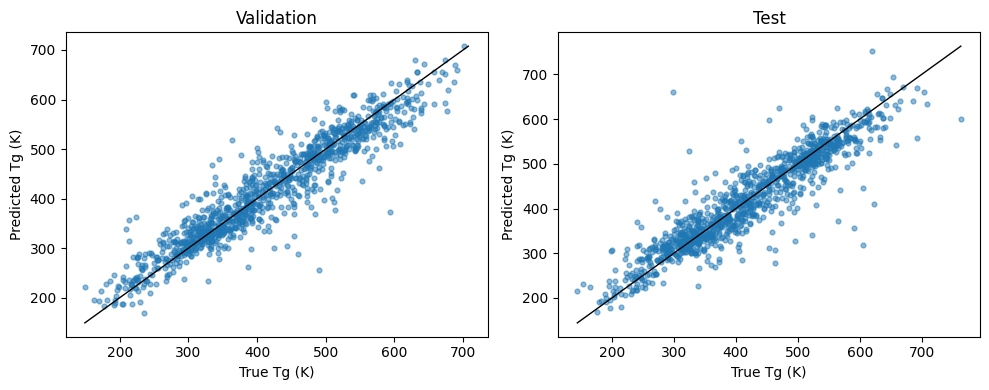

In [32]:
best_model = XGBoostModel(n_estimators=best_n_estimator, learning_rate=best_learning_rate)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

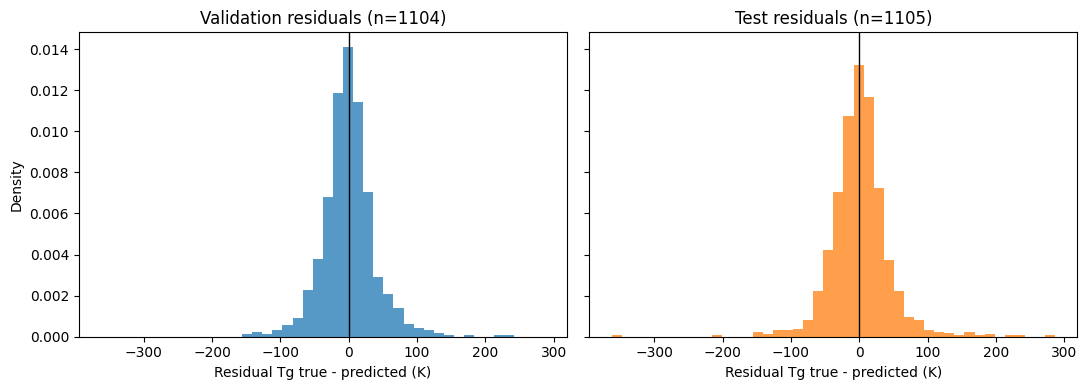

In [33]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()

# SVM

In [ ]:
C_list = np.logspace(start=2, stop=3, num=2, endpoint=True)
gamma_list = np.logspace(start=-5, stop=-2, num=2, endpoint=True)
epsilon_list = np.linspace(start=0.5, stop=0.9, num=3, endpoint=True)
svm_results = []

for C in C_list:
    for gamma in gamma_list:
        for epsilon in epsilon_list:
            model = SupportVectorModel(C=C, gamma=gamma, epsilon=epsilon)
            y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
            scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
            scores["C"] = C
            scores["gamma"] = gamma
            scores["epsilon"] = epsilon
            svm_results.append(scores)

In [11]:
best_result = min(svm_results, key=lambda result: result["rmse_validation"])
best_C = best_result["C"]
best_gamma = best_result["gamma"]
best_epsilon = best_result["epsilon"]

print("Best C by validation RMSE:", best_C)
print("Best gamma by validation RMSE:", best_gamma)
print("Best epsilon by validation RMSE:", best_epsilon)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best C by validation RMSE: 1000.0
Best gamma by validation RMSE: 1e-05
Best epsilon by validation RMSE: 0.9
mse_validation: 2062.2558
mse_test: 2247.7586
mae_validation: 32.9129
mae_test: 33.4244
rmse_validation: 45.4121
rmse_test: 47.4105
r2_validation: 0.8393
r2_test: 0.8177
C: 1000.0000
gamma: 0.0000
epsilon: 0.9000


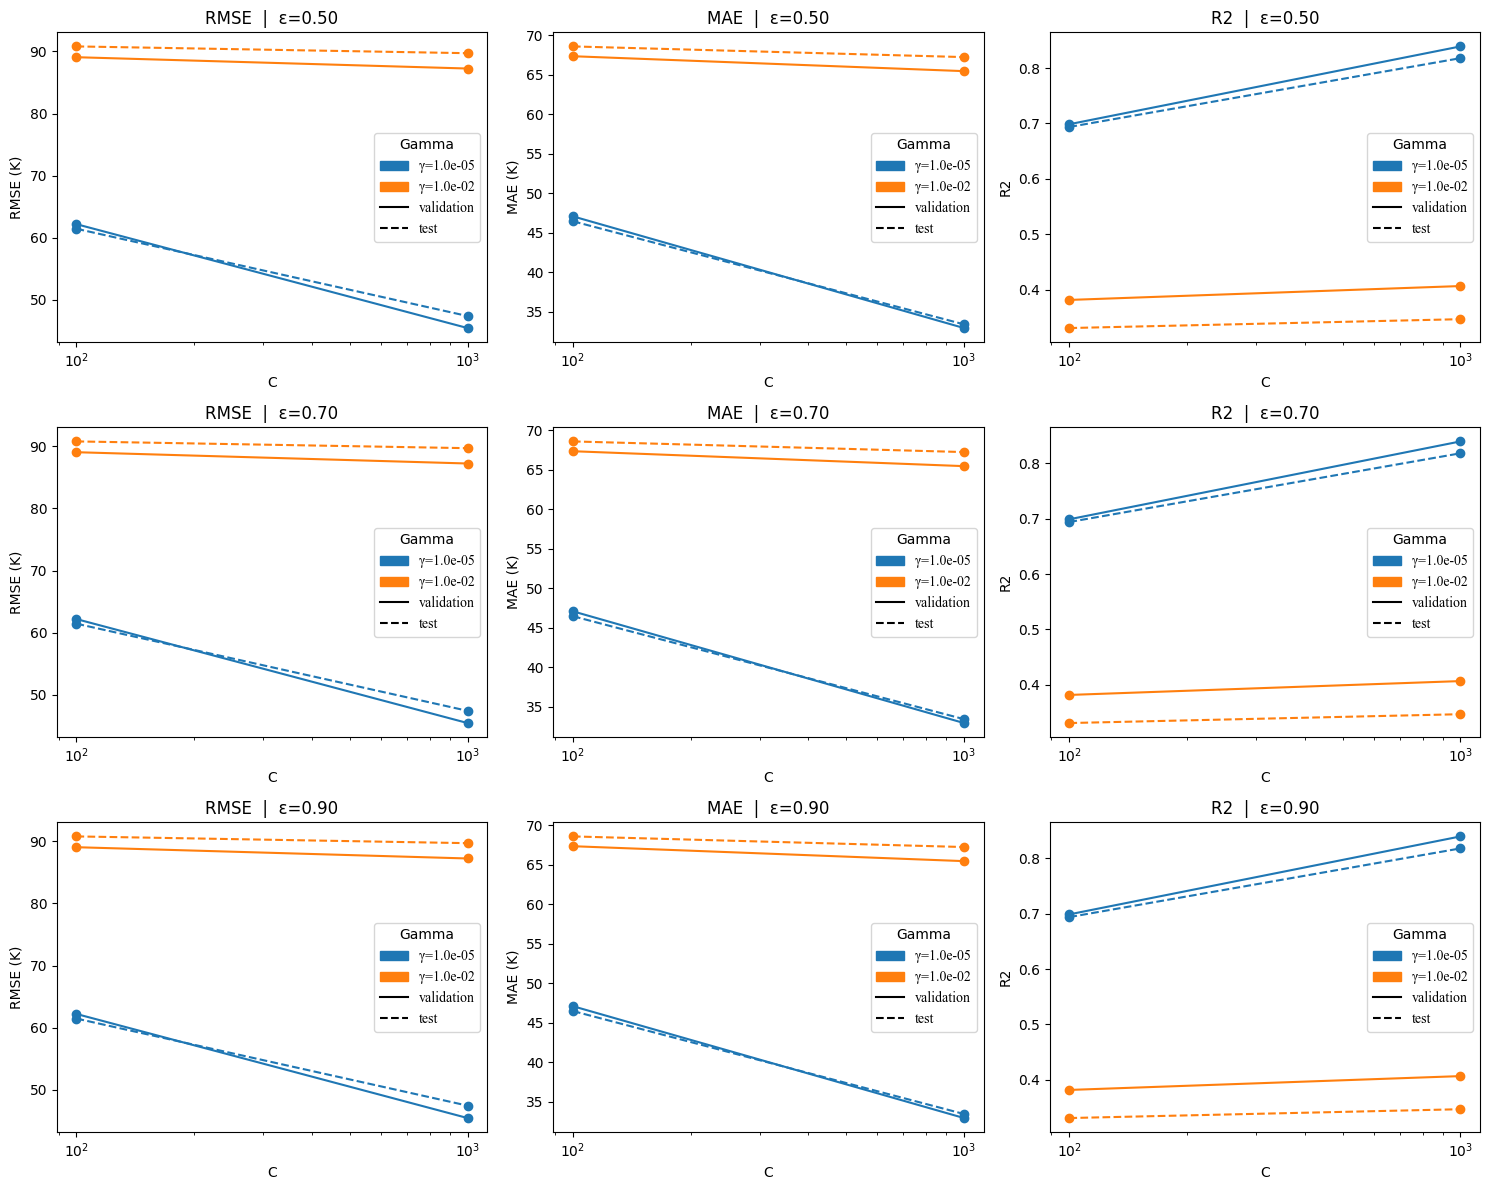

In [12]:
# ── Valeurs uniques des 3 paramètres ──────────────────────────────────────────
C_values       = np.unique([result["C"]       for result in svm_results])
gamma_values   = np.unique([result["gamma"]   for result in svm_results])
epsilon_values = np.unique([result["epsilon"] for result in svm_results])

# ── Couleur par valeur de gamma (4 valeurs) ───────────────────────────────────
tab_colors = ["tab:blue", "tab:orange"]#, "tab:green"]#, "tab:red"]
gamma_color_map = {round(g, 6): c for g, c in zip(gamma_values, tab_colors)}

# ── Grille : lignes = epsilon, colonnes = métriques ───────────────────────────
n_rows = len(epsilon_values)   # 3
n_cols = 3                     # RMSE | MAE | R2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False)

metrics = [
    ("rmse_validation", "rmse_test", "RMSE (K)", "RMSE"),
    ("mae_validation",  "mae_test",  "MAE (K)",  "MAE"),
    ("r2_validation",   "r2_test",   "R2",       "R2"),
]

for row_idx, epsilon in enumerate(epsilon_values):
    for col_idx, (val_key, test_key, ylabel, title) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        for gamma in gamma_values:
            color = gamma_color_map[round(gamma, 6)]

            # Subset : epsilon ET gamma fixes, C varie
            subset = [
                r for r in svm_results
                if round(r["epsilon"], 6) == round(epsilon, 6)
                and round(r["gamma"],   6) == round(gamma,   6)
            ]
            subset.sort(key=lambda r: r["C"])

            x      = np.array([r["C"]       for r in subset])
            y_val  = np.array([r[val_key]   for r in subset])
            y_test = np.array([r[test_key]  for r in subset])

            ax.plot(x, y_val,  marker="o", linestyle="-",  color=color)
            ax.plot(x, y_test, marker="o", linestyle="--", color=color)

        ax.set_xscale("log")
        ax.set_xlabel("C")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}  |  ε={epsilon:.2f}")

# ── Légende commune ───────────────────────────────────────────────────────────
line_val  = mlines.Line2D([], [], color='black', linestyle='-',  label='validation')
line_test = mlines.Line2D([], [], color='black', linestyle='--', label='test')
gamma_patches = [
    mpatches.Patch(color=gamma_color_map[round(g, 6)], label=f'γ={g:.1e}')
    for g in gamma_values
]

for row_idx in range(n_rows):
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].legend(
            handles=[*gamma_patches, line_val, line_test],
            loc='best', ncol=1, title='Gamma',
            prop={'family': 'Times New Roman', 'size': 10}
        )

plt.tight_layout()
plt.show()

## Best SVM predictions

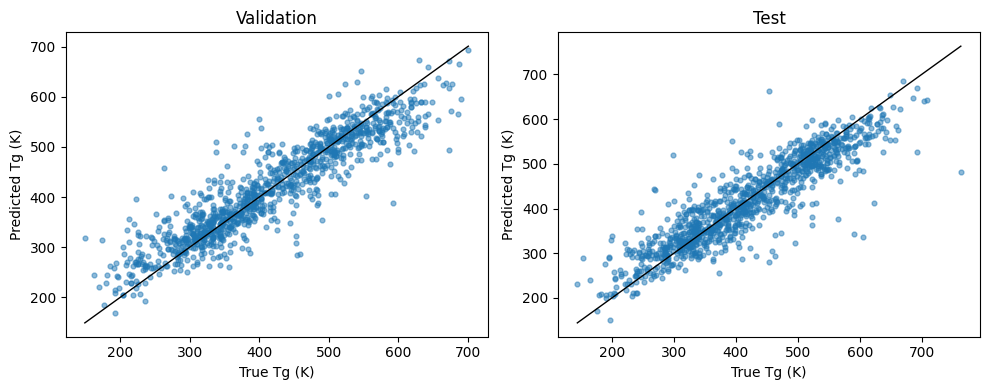

In [21]:
best_model = SupportVectorModel(C=best_C, gamma=best_gamma, epsilon=best_epsilon)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

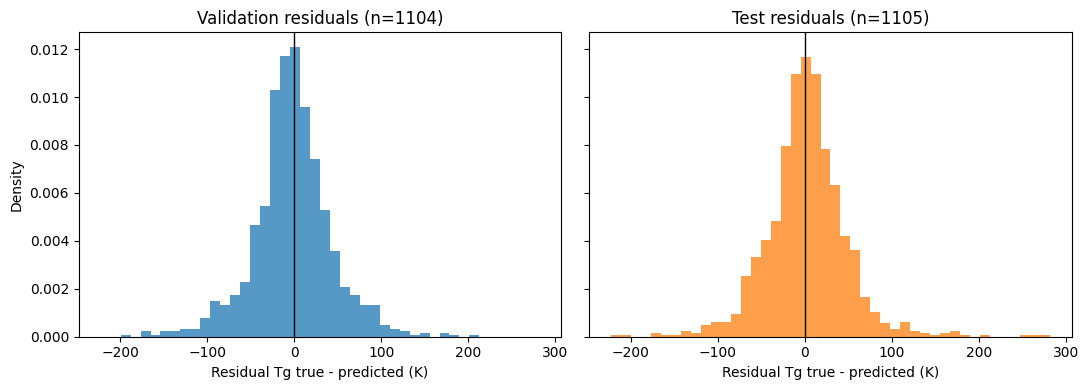

In [22]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()

# Ensemble

In [46]:
best_model_elastic_net = ElasticNetModel(alpha=0.01, l1_ratio=0.85)
best_model_xgboost = XGBoostModel(n_estimators=150, learning_rate=0.3)
best_model_random_forest = RandomForest(n_estimators=80)

y_pred_validation_en, y_pred_test_en = fit_and_predict(best_model_elastic_net, X_train, y_train, X_validation, X_test)
y_pred_validation_xgb, y_pred_test_xgb = fit_and_predict(best_model_xgboost, X_train, y_train, X_validation, X_test)
y_pred_validation_rf, y_pred_test_rf = fit_and_predict(best_model_random_forest, X_train, y_train, X_validation, X_test)

y_pred_validation = (y_pred_validation_en + y_pred_validation_xgb + y_pred_validation_rf) / 3
y_pred_test = (y_pred_test_en + y_pred_test_xgb + y_pred_test_rf) / 3
scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
for key, value in scores.items():
    print(f"{key}: {value:.4f}")

mse_validation: 1356.9910
mse_test: 1666.9066
mae_validation: 26.5211
mae_test: 27.3952
rmse_validation: 36.8374
rmse_test: 40.8278
r2_validation: 0.8943
r2_test: 0.8648


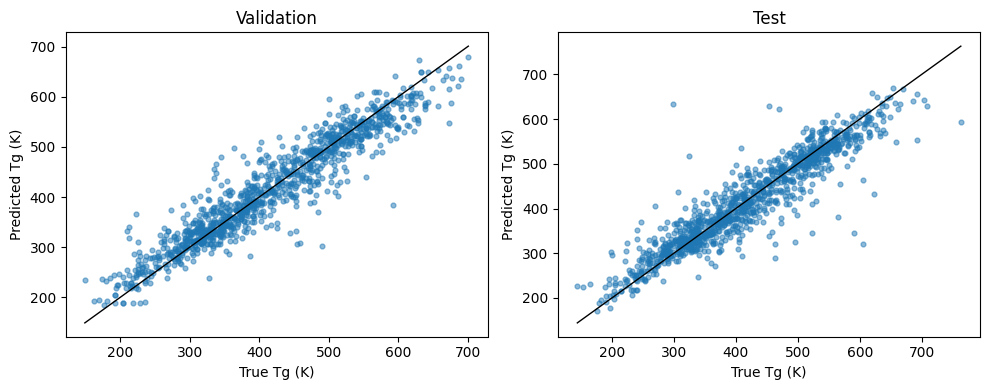

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

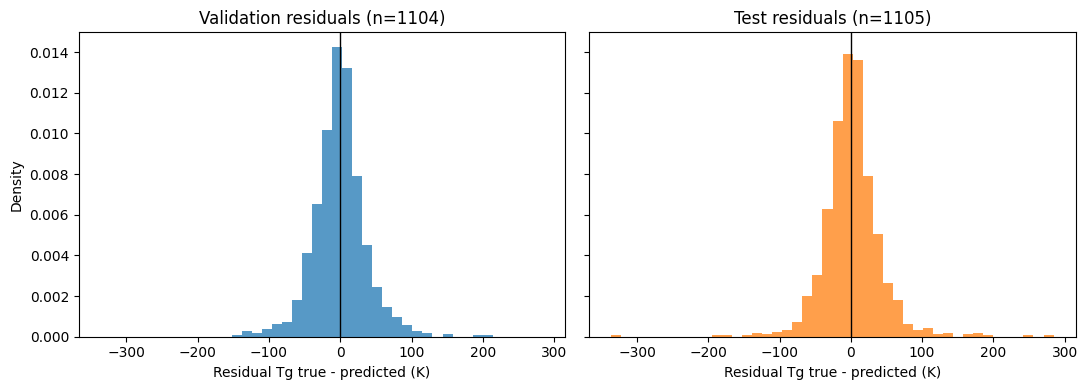

In [48]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()